In [1]:
import sklearn
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

import torch
from torch import nn
import torchmetrics

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from src.models import CircleBinClassModel
from src.metrics_funcs import get_accuracy
from src.plotting_helpers import plot_decision_boundary, plot_curves

In [2]:
# Device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

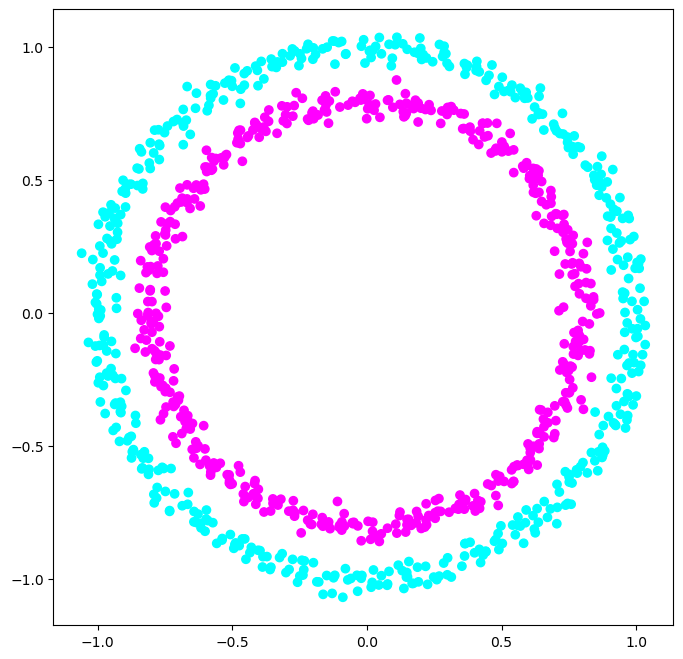

In [3]:
# Make custom dataset
n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)

# Visualize
plt.figure(figsize=(8, 8))
plt.scatter(x=X[:, 0], y=X[:, 1], c=y, cmap=plt.cm.cool)
plt.show()

In [4]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [5]:
# Split data using built-in sklearn function
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=16
)

# Move to device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [6]:
# Create a model instance
model_0 = CircleBinClassModel().to(device)

In [7]:
# Define loss and optimizer
loss_func = nn.BCEWithLogitsLoss() # <=> Sigmoid + Binary Cross Entropy Loss
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [8]:
# Initialize with random seed for reproducibility
torch.manual_seed(16)
torch.cuda.manual_seed(16)

EPOCHS = 1000

# Track loss
save_step = 50
train_loss_vals = []
test_loss_vals = []
train_acc_vals = []
test_acc_vals = []

# Training loop
for epoch in range(EPOCHS):
    model_0.train()

    # Forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # Calculate loss and accuracy
    loss = loss_func(y_logits, y_train)
    accuracy = get_accuracy(y_true=y_train, y_pred=y_pred)

    # Zero out gradients
    optimizer.zero_grad()

    # Backward propagation
    loss.backward()

    # Step the optimizer
    optimizer.step()

    # Testing loop
    model_0.eval()
    with torch.inference_mode():
        # Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # Calculate loss and accuracy
        test_loss = loss_func(test_logits, y_test)
        test_accuracy = get_accuracy(y_true=y_test, y_pred=test_pred)

    # Print progress
    if epoch % save_step == 0:
        print(f"Epoch: {epoch}")
        print(f"Loss: {loss:.5f} | Acc: {accuracy:.2f}")
        print(f"Test Loss: {test_loss:.5f} | Test Acc: {test_accuracy:.2f}")
        train_loss_vals.append(loss)
        test_loss_vals.append(test_loss)
        train_acc_vals.append(accuracy)
        test_acc_vals.append(test_accuracy)
        print("-----------------------------------------------------------------")

Epoch: 0
Loss: 0.70070 | Acc: 50.12
Test Loss: 0.70233 | Test Acc: 49.50
-----------------------------------------------------------------
Epoch: 50
Loss: 0.68883 | Acc: 53.25
Test Loss: 0.69100 | Test Acc: 49.00
-----------------------------------------------------------------
Epoch: 100
Loss: 0.68638 | Acc: 52.50
Test Loss: 0.68897 | Test Acc: 47.50
-----------------------------------------------------------------
Epoch: 150
Loss: 0.68344 | Acc: 56.50
Test Loss: 0.68666 | Test Acc: 53.00
-----------------------------------------------------------------
Epoch: 200
Loss: 0.67966 | Acc: 63.00
Test Loss: 0.68374 | Test Acc: 57.50
-----------------------------------------------------------------
Epoch: 250
Loss: 0.67439 | Acc: 67.25
Test Loss: 0.67932 | Test Acc: 63.50
-----------------------------------------------------------------
Epoch: 300
Loss: 0.66756 | Acc: 70.25
Test Loss: 0.67342 | Test Acc: 65.00
-----------------------------------------------------------------
Epoch: 350
Loss:

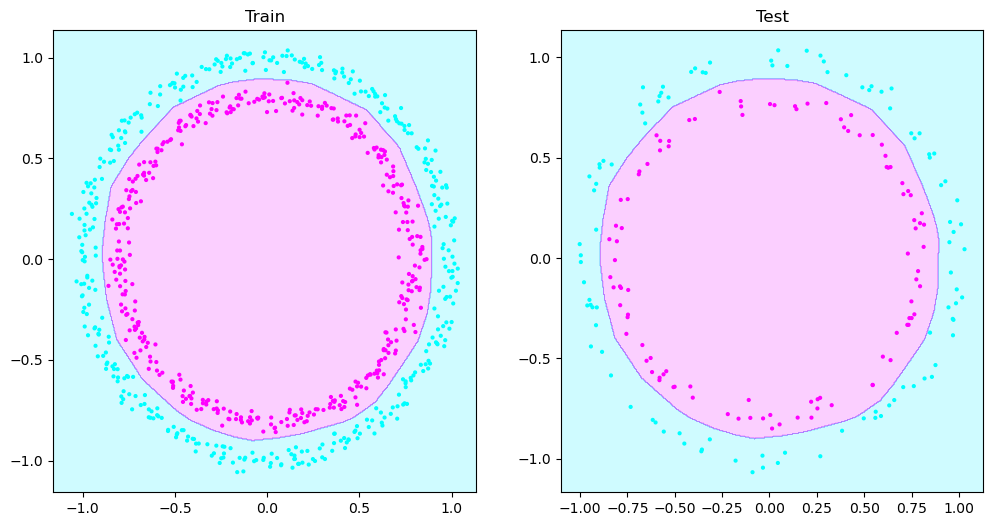

In [9]:
# Visualize results
plt.figure(figsize=(12, 6))

# Training set
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)

# Testing set
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

plt.savefig("example_circles_bin_class_model.png")

plt.show()

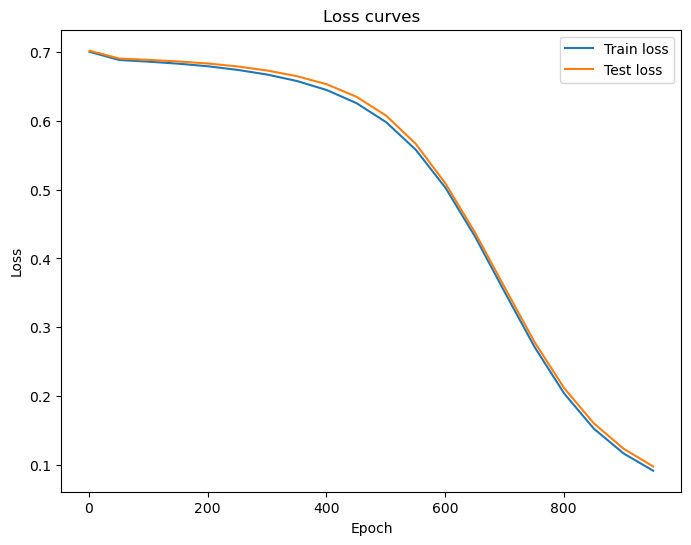

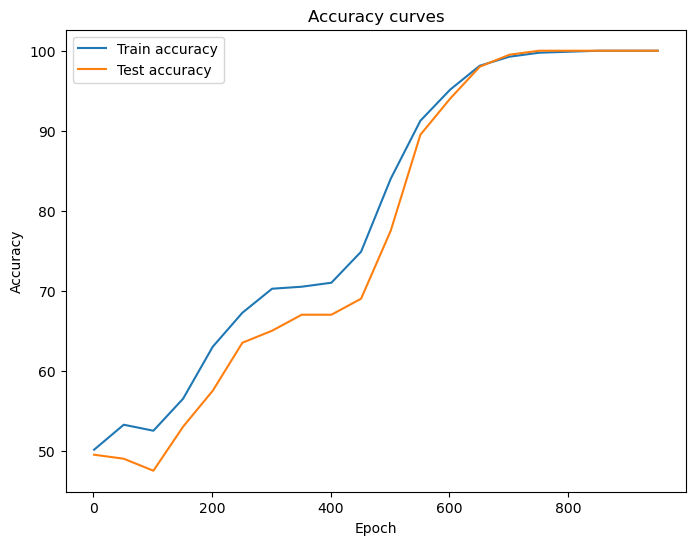

In [10]:
epoch_count = np.arange(1, EPOCHS, save_step)
plot_curves(epoch_count, train_loss_vals, test_loss_vals, var_to_plot="loss", filename="loss_curve.png")
plot_curves(epoch_count, train_acc_vals, test_acc_vals, var_to_plot="accuracy", filename="accuracy_curve.png")

In [11]:
# Saving the model
model_path = Path.cwd() / "models"
model_path.mkdir(parents=True, exist_ok=True)
model_name = "example_circles_bin_class_model.pth"
model_save_path = model_path / model_name

torch.save(obj=model_0.state_dict(), f=model_save_path)